# IndoBERT Modeling

[1] Data Split = 70:15:15

[2] Pretrained Model = indobenchmark/indobert-base-p1

[3] Data Processing = Tokenization (padding, truncation, max_len=128)

[4] Batch Size = 16

[5] Imbalance Handling = Class Weighting (CrossEntropyLoss)

[6] Model Architecture = IndoBERT

[7] Optimizer = AdamW (lr=2e-5)

[8] Training = 3 Epochs + Gradient Clipping (1.0)

[9] Validation = Stratified 3-Fold Cross Validation

[10] Evaluation = Classification Report (Macro F1-Scroe, Accuracy, Precision, Recall), Confusion Matrix, Inference Time

## Import Library

In [ ]:
import pickle                  # Serialisasi model / object
import numpy as np             # Operasi numerik
import pandas as pd            # Manipulasi data
import random

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Framework deep learning berbasis PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader # Batching
from torch.optim import AdamW  # Optimizer umum untuk fine-tuning Transformer

# Scikit-learn (Data & Evaluation)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight

# HuggingFace Transformers (PyTorch)
import transformers
from transformers import (
    AutoTokenizer,                          # Tokenizer pretrained
    AutoModelForSequenceClassification      # Model klasifikasi berbasis Transformer
)

In [ ]:
# Menghubungkan Drive ke Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Device Configuration
# Gunakan GPU jika tersedia, jika tidak fallback ke CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"[INFO] Device yang digunakan: {device}")
if device.type == "cuda":
    print(f"[INFO] GPU: {torch.cuda.get_device_name(0)}")

[INFO] Device yang digunakan: cuda
[INFO] GPU: Tesla T4


### Environtment Detail

In [ ]:
import platform
import sys

# System
print('System Information')
print(f'OS                : {platform.system()} {platform.release()}')
print(f'Processor         : {platform.processor()}')
print(f'Python Version    : {sys.version.split()[0]}')

# GPU
print('\nGPU')
if torch.cuda.is_available():
    print(f"GPU Name          : {torch.cuda.get_device_name(0)}")
    print(f"CUDA Available    : Yes")
else:
    print("GPU tidak tersedia")

# Library
print('Library Versions')
print(f'NumPy             : {np.__version__}')
print(f'Pandas            : {pd.__version__}')
print(f'PyTorch           : {torch.__version__}')

System Information
OS                : Linux 6.6.113+
Processor         : x86_64
Python Version    : 3.12.13

GPU
GPU Name          : Tesla T4
CUDA Available    : Yes
Library Versions
NumPy             : 2.0.2
Pandas            : 2.2.2
PyTorch           : 2.10.0+cu128


## Load & Eksplorasi Data

In [ ]:
# Load dataset dari file CSV
path = '/content/drive/MyDrive/skripsi/svm_indobert/data/final_data/krl_complaints_preprocessed_4.csv'
df = pd.read_csv(path)

# Tampilkan 5 baris pertama untuk verifikasi data berhasil dimuat
print(df.head())

                                           full_text  \
0  @CommuterLine @suckislife_ @perkeretaapian Nge...   
1  @CommuterLine 5517 telat 50 menit kenapa masuk...   
2  @CommuterLine itu papan jadwal cisauk jalur 2 ...   
3  @CommuterLine @jalur5_ Klo kyk gini petugasnya...   
4  @CommuterLine Penataran Malang-SBY pukul jam 3...   

                                            text_svm  \
0             ngeri tangga tidak kuat banyak manusia   
1  angka telat angka menit masuk lokasi_stasiun a...   
2  papan jadwal lokasi_stasiun jalur angka tidak ...   
3  kalau begini tugas bantu astaga mau gendong ka...   
4  natar malang surabaya pukul jam 3an angka des ...   

                                           text_bert          label  
0  ngeri tangganya enggak kuat min itu banyak ban...       Keamanan  
1  5517 telat 50 menit kenapa masuk bks harusnya ...  Keterlambatan  
2  itu papan jadwal cisauk jalur 2 enggak update ...  Keterlambatan  
3  kalo kayak begini petugasnya bantu apa anji

In [ ]:
# Dictionary Label untuk mapping label kategori ke angka
label_map = {
    'Keterlambatan' : 0,
    'Pelayanan'     : 1,
    'Kepadatan'     : 2,
    'Keamanan'      : 3,
    'Kebersihan'    : 4
}

# Encode kolom 'label' menjadi numerik sesuai label_map
df['label_encoded'] = df['label'].map(label_map)

# Inisialisasi LabelEncoder untuk keperluan decoding/evaluasi
le = LabelEncoder()

# Set urutan kelas berdasarkan nilai encoding agar konsisten saat evaluasi
le.classes_ = np.array(sorted(label_map, key=label_map.get))

In [ ]:
# Ringkasan Dataset
print('  INFORMASI DATASET')
print(f"  Total sampel  : {len(df)}")
print(f"  Jumlah kelas  : {df['label'].nunique()}")
print(f"  Nama kelas    : {list(le.classes_)}")


  INFORMASI DATASET
  Total sampel  : 4918
  Jumlah kelas  : 5
  Nama kelas    : [np.str_('Keterlambatan'), np.str_('Pelayanan'), np.str_('Kepadatan'), np.str_('Keamanan'), np.str_('Kebersihan')]


In [ ]:
# Distribusi Kelas (Jumlah & Persentase)
# Hitung frekuensi tiap kelas
dist       = df['label'].value_counts()

# Hitung persentase tiap kelas
dist_pct   = dist / dist.sum() * 100

# Tampilkan tabel distribusi
dist_table = pd.DataFrame({
    'Frekuensi'     : dist,
    'Persentase (%)': dist_pct.round(2)
})
print('\n  Distribusi Label')
print(dist_table.to_string())


  Distribusi Label
               Frekuensi  Persentase (%)
label                                   
Keterlambatan       1627           33.08
Pelayanan           1276           25.95
Kepadatan           1236           25.13
Keamanan             527           10.72
Kebersihan           252            5.12


In [ ]:
# Hitung rasio imbalance (kelas terbesar dibanding terkecil)
ratio = dist.max() / dist.min()

print(f"\n  Imbalance Ratio (kelas terbesar / terkecil) : {ratio:.2f}x")
print(f"  Kelas mayoritas  : {dist.idxmax()} ({dist.max()} sampel)")
print(f"  Kelas minoritas  : {dist.idxmin()} ({dist.min()} sampel)")


  Imbalance Ratio (kelas terbesar / terkecil) : 6.46x
  Kelas mayoritas  : Keterlambatan (1627 sampel)
  Kelas minoritas  : Kebersihan (252 sampel)


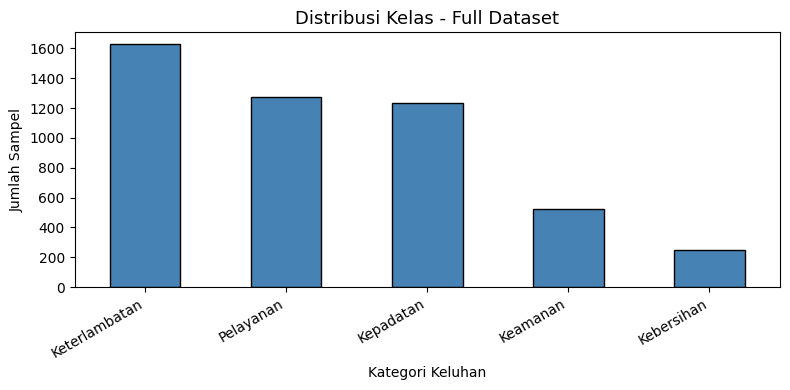

In [ ]:
# Visualisasi Distribusi Full Dataset
plt.figure(figsize=(8, 4))
dist.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribusi Kelas - Full Dataset', fontsize=13)
plt.xlabel('Kategori Keluhan')
plt.ylabel('Jumlah Sampel')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Data Splitting

In [ ]:
# 70:15:15
# 1: 70% train, 30% sementara (val + test)
X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(
    df['text_bert'],
    df['label_encoded'],
    test_size=0.30,
    stratify=df['label_encoded'],  # menjaga distribusi label
    random_state=42
)

In [ ]:
# 2: 30% → 15% validation + 15% test
X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [ ]:
# Konversi ke numpy array (dibutuhkan untuk indexing saat CV)
X_tr, y_tr = X_train_raw.values, y_train_raw.values
X_v,  y_v  = X_val_raw.values,   y_val_raw.values
X_te, y_te = X_test_raw.values,  y_test_raw.values

# Jumlah kelas (output neuron)
num_classes = len(le.classes_)

In [ ]:
print(f"\n  Ukuran Split:")
print(f"  Train : {len(X_tr)} sampel ({len(X_tr)/len(df)*100:.1f}%)")
print(f"  Val   : {len(X_v)} sampel ({len(X_v)/len(df)*100:.1f}%)")
print(f"  Test  : {len(X_te)} sampel ({len(X_te)/len(df)*100:.1f}%)")


  Ukuran Split:
  Train : 3442 sampel (70.0%)
  Val   : 738 sampel (15.0%)
  Test  : 738 sampel (15.0%)


In [ ]:
def print_split_dist(y, split_name, le):
    '''Menampilkan jumlah dan persentase tiap kelas dalam satu subset data.'''
    series = pd.Series(le.inverse_transform(y)) # Decode label numerik → label asli
    counts = series.value_counts().sort_index() # Hitung jumlah per kelas (urut konsisten)
    total = len(y)

    print(f"\n[{split_name}] — {total} sampel")

    for label, count in counts.items():
        percentage = (count / total) * 100
        print(f"  {label:<20} : {count:>4} ({percentage:5.1f}%)")

Distribusi Kelas Per Split

[TRAIN  (70%)] — 3442 sampel
  Keamanan             :  369 ( 10.7%)
  Kebersihan           :  176 (  5.1%)
  Kepadatan            :  865 ( 25.1%)
  Keterlambatan        : 1139 ( 33.1%)
  Pelayanan            :  893 ( 25.9%)

[VAL    (15%)] — 738 sampel
  Keamanan             :   79 ( 10.7%)
  Kebersihan           :   38 (  5.1%)
  Kepadatan            :  186 ( 25.2%)
  Keterlambatan        :  244 ( 33.1%)
  Pelayanan            :  191 ( 25.9%)

[TEST   (15%)] — 738 sampel
  Keamanan             :   79 ( 10.7%)
  Kebersihan           :   38 (  5.1%)
  Kepadatan            :  185 ( 25.1%)
  Keterlambatan        :  244 ( 33.1%)
  Pelayanan            :  192 ( 26.0%)


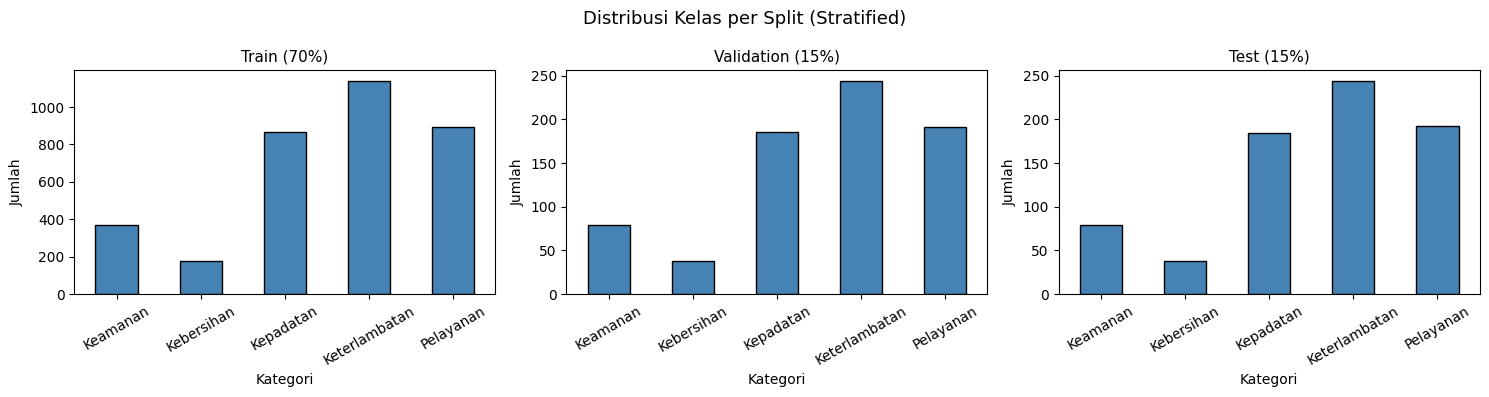

In [ ]:
print('Distribusi Kelas Per Split')
print_split_dist(y_tr,  'TRAIN  (70%)', le)   # Distribusi data training
print_split_dist(y_v,   'VAL    (15%)', le)   # Distribusi data validasi
print_split_dist(y_te,  'TEST   (15%)', le)   # Distribusi data testing

# Visualisasi Distribusi Kelas Per Split [Bar Chart]
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))

# Daftar dataset split beserta judulnya
splits = [
    (y_tr, "Train (70%)"),
    (y_v,  "Validation (15%)"),
    (y_te, "Test (15%)")
]

# Loop setiap subplot (ax) dan pasangan data split
for ax, (y_split, title) in zip(axes, splits):

    # Decode label numerik menjadi label asli (string)
    labels = le.inverse_transform(y_split)

    counts = (
        pd.Series(labels) # ubah ke Series
        .value_counts()   # hitung frekuensi
        .sort_index()     # urut berdasarkan nama label

    )

    # Membuat bar chart dari distribusi kelas
    counts.plot(
        kind='bar',        # tipe plot: bar chart
        ax=ax,             # plot ke subplot saat ini
        color='steelblue', # warna bar
        edgecolor='black'  # warna garis tepi bar
    )

    # Mengatur judul tiap subplot
    ax.set_title(title, fontsize=11)

    # Label sumbu X (kategori kelas)
    ax.set_xlabel('Kategori')

    # Label sumbu Y (jumlah data)
    ax.set_ylabel('Jumlah')

    # Mengatur rotasi label pada sumbu X agar tidak bertumpuk
    ax.tick_params(axis='x', rotation=30)

# Menambahkan judul utama untuk seluruh figure
fig.suptitle('Distribusi Kelas per Split (Stratified)', fontsize=13)

# Merapikan layout agar tidak saling bertabrakan
plt.tight_layout()

# Menampilkan plot ke layar
plt.show()

## Tokenization (IndoBERT) & Dataset Class

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [ ]:
# Konfigurasi
LOCAL_PATH = "/content/drive/MyDrive/skripsi/svm_indobert/model/indobert_local"  # simpan di Drive

set_seed(42)                                           # 1. Fix seed
tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")  # 2. Tokenizer
hf_model  = AutoModelForSequenceClassification.from_pretrained(              # 3. Model
    "indobenchmark/indobert-base-p1", num_labels=num_classes
)
hf_model.save_pretrained(LOCAL_PATH)                   # 4. Simpan ke Drive
tokenizer.save_pretrained(LOCAL_PATH)
HF_CHECKPOINT = LOCAL_PATH                             # 5. Set path lokal

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# Parameter preprocessing & training
MAX_LEN    = 128   # Maksimum panjang token
BATCH_SIZE = 16    # Jumlah data per batch
MODEL_NAME    = "IndoBERT_Baseline_Weighted"
LEARNING_RATE = 2e-5
EPOCHS        = 3

In [ ]:
# Dataset Class (PyTorch)
class TextDataset(Dataset):
    """
    Dataset custom untuk PyTorch:
    Mengubah teksdata mentah (teks + label) jadi format yang bisa dipahami PyTorch dan model IndoBERT
    """

    def __init__(self, texts, labels=None):
        # Tokenisasi seluruh teks di awal (lebih efisien dibanding per item)
        self.encodings = tokenizer(
            texts.tolist(),      # Pastikan input berupa list
            padding=True,        # Padding agar panjang sama
            truncation=True,     # Potong jika melebihi MAX_LEN
            max_length=MAX_LEN
        )

        self.labels = labels     # Label bisa None (untuk inference)

    def __len__(self):
        # Mengembalikan jumlah sampel
        return len(self.encodings["input_ids"])

    def __getitem__(self, idx):
        """
        Mengambil satu data (dipanggil otomatis oleh DataLoader)
        """
        # Ambil setiap komponen encoding dan ubah ke tensor
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        # Tambahkan label jika tersedia (mode training/evaluasi)
        if self.labels is not None:
            item["labels"] = torch.tensor(
                self.labels[idx],
                dtype=torch.long  # Harus long untuk classification
            )

        return item

In [ ]:
# Dataloader Function
def get_dataloader(X, y, shuffle=False):
    """
    Membuat DataLoader dari teks dan label.
    DataLoader bertugas:
    - batching
    - shuffling
    - feeding data ke model
    """
    dataset = TextDataset(X, y)
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle
    )

In [ ]:
# DataLoader Per Split
# Train: shuffle aktif agar model tidak belajar dari urutan data
train_loader = get_dataloader(X_tr, y_tr, shuffle=True)

# Validation & Test: tidak perlu shuffle (agar konsisten evaluasi)
val_loader  = get_dataloader(X_v,  y_v,  shuffle=False)
test_loader = get_dataloader(X_te, y_te, shuffle=False)

In [ ]:
# Dataloader Information
print("\nKonfigurasi DataLoader")
print(f"  MAX_LEN    : {MAX_LEN}")
print(f"  BATCH_SIZE : {BATCH_SIZE}")

print("\nJumlah Batch")
print(f"  Train : {len(train_loader)}")
print(f"  Val   : {len(val_loader)}")
print(f"  Test  : {len(test_loader)}")


Konfigurasi DataLoader
  MAX_LEN    : 128
  BATCH_SIZE : 16

Jumlah Batch
  Train : 216
  Val   : 47
  Test  : 47


## Model Training & Cross-Validation

In [ ]:
def build_model():
    """
    Load IndoBERT
    """
    model = AutoModelForSequenceClassification.from_pretrained(
        HF_CHECKPOINT,
        num_labels=num_classes
    )
    return model.to(device)

In [ ]:
# Handle Class Imbalance
# Hitung class weight dari data training
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_tr),
    y=y_tr
)

# Convert ke tensor (wajib di device)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# Loss function dengan class weight
loss_fn = nn.CrossEntropyLoss(weight=class_weights)

In [ ]:
# Training Function
def train_one_epoch(model, dataloader, optimizer, loss_fn):
    """
    Training 1 epoch:
    - forward
    - backward
    - update weight
    """
    model.train()

    total_loss, correct, total = 0, 0, 0

    for batch in dataloader:
        labels = batch.pop("labels").to(device)
        inputs = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()

        outputs = model(**inputs)
        loss = loss_fn(outputs.logits, labels)

        loss.backward()

        # Gradient clipping → stabilitas training
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()

        preds = outputs.logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(dataloader), correct / total

In [ ]:
# Evaluation Function
def evaluate_model(model, dataloader, loss_fn):
    """
    Evaluasi model (tanpa update weight)
    """
    model.eval()

    total_loss, correct, total = 0, 0, 0
    all_preds = []

    with torch.no_grad():
        for batch in dataloader:
            labels = batch.pop("labels").to(device)
            inputs = {k: v.to(device) for k, v in batch.items()}

            outputs = model(**inputs)
            loss = loss_fn(outputs.logits, labels)

            total_loss += loss.item()

            preds = outputs.logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())

    return total_loss / len(dataloader), correct / total, np.array(all_preds)

In [ ]:
# 3-Fold Cross Validation
print(f"\n[INFO] 3-Fold CV — {MODEL_NAME}")

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_tr, y_tr), 1):
    print(f"\n  Fold {fold}/3")

    set_seed(42)  # fix seed tiap fold

    fold_train_loader = get_dataloader(X_tr[train_idx], y_tr[train_idx], shuffle=True)
    fold_val_loader   = get_dataloader(X_tr[val_idx],   y_tr[val_idx],   shuffle=False)

    model = build_model()
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

    for epoch in range(3):
        print(f"  Epoch {epoch+1}/3")
        train_one_epoch(model, fold_train_loader, optimizer, loss_fn)

    # Evaluasi
    _, _, preds = evaluate_model(model, fold_val_loader, loss_fn)

    acc = accuracy_score(y_tr[val_idx], preds)
    f1  = f1_score(y_tr[val_idx], preds, average="macro")

    fold_results.append({"fold": fold, "accuracy": acc, "macro_f1": f1})
    print(f"  Fold {fold} | Acc: {acc:.4f} | Macro-F1: {f1:.4f}")

    # Bebaskan memori GPU
    del model, optimizer, fold_train_loader, fold_val_loader
    torch.cuda.empty_cache()

# Ringkasan CV
accs = np.array([r["accuracy"] for r in fold_results])
f1s  = np.array([r["macro_f1"] for r in fold_results])

print(f"\n{'='*40}")
print(f"[CV] Accuracy per fold  : {np.round(accs, 4)}")
print(f"[CV] Accuracy Mean±Std  : {accs.mean():.4f} ± {accs.std():.4f}")
print(f"[CV] F1 Macro per fold  : {np.round(f1s, 4)}")
print(f"[CV] F1 Macro Mean±Std  : {f1s.mean():.4f} ± {f1s.std():.4f}")


[INFO] 3-Fold CV — IndoBERT_Baseline_Weighted

  Fold 1/3


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Epoch 1/3
  Epoch 2/3
  Epoch 3/3
  Fold 1 | Acc: 0.7953 | Macro-F1: 0.7996

  Fold 2/3


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Epoch 1/3
  Epoch 2/3
  Epoch 3/3
  Fold 2 | Acc: 0.7768 | Macro-F1: 0.7937

  Fold 3/3


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Epoch 1/3
  Epoch 2/3
  Epoch 3/3
  Fold 3 | Acc: 0.7855 | Macro-F1: 0.7966

[CV] Accuracy per fold  : [0.7953 0.7768 0.7855]
[CV] Accuracy Mean±Std  : 0.7859 ± 0.0076
[CV] F1 Macro per fold  : [0.7996 0.7937 0.7966]
[CV] F1 Macro Mean±Std  : 0.7966 ± 0.0024


## Final Model Training

In [ ]:
set_seed(42)  # fix random state agar reproducible
print(f"\n[INFO] Final Training — {MODEL_NAME}")

final_model = build_model()
optimizer   = AdamW(final_model.parameters(), lr=LEARNING_RATE)  # optimizer standar untuk fine-tuning BERT

# Menyimpan metrik tiap epoch untuk keperluan plotting dan analisis
history = {
    "train_loss": [], "val_loss": [],
    "train_acc":  [], "val_acc":  [],
    "val_f1":     []
}
best_val_f1 = 0  # penanda model terbaik

for epoch in range(EPOCHS):
    # Training satu epoch, bobot model diupdate
    tr_loss, tr_acc = train_one_epoch(final_model, train_loader, optimizer, loss_fn)

    # Evaluasi di val set, bobot tidak diupdate
    vl_loss, vl_acc, preds = evaluate_model(final_model, val_loader, loss_fn)
    vl_f1 = f1_score(y_v, preds, average="macro")  # metrik utama pelaporan

    # Catat semua metrik
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    history["val_f1"].append(vl_f1)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train Loss: {tr_loss:.4f} | Acc: {tr_acc:.4f}")
    print(f"  Val   Loss: {vl_loss:.4f} | Acc: {vl_acc:.4f} | F1: {vl_f1:.4f}")

    # Simpan model hanya jika F1 validasi membaik — hindari simpan model yang overfitting
    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        torch.save(final_model.state_dict(), "best_model.pt")
        print(f"  ✓ Best model saved (F1: {vl_f1:.4f})")

print(f"\n[INFO] Training selesai. Best Val F1: {best_val_f1:.4f}")


[INFO] Final Training — IndoBERT_Baseline_Weighted


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Epoch 1/3
  Train Loss: 0.8410 | Acc: 0.6772
  Val   Loss: 0.5156 | Acc: 0.8062 | F1: 0.8173
  ✓ Best model saved (F1: 0.8173)
Epoch 2/3
  Train Loss: 0.4332 | Acc: 0.8359
  Val   Loss: 0.5380 | Acc: 0.7846 | F1: 0.7890
Epoch 3/3
  Train Loss: 0.2574 | Acc: 0.8934
  Val   Loss: 0.6089 | Acc: 0.7710 | F1: 0.7877

[INFO] Training selesai. Best Val F1: 0.8173


## Validation Evaluation

In [ ]:
# Validation Prediction
_, _, val_preds = evaluate_model(final_model, val_loader, loss_fn)


Classification Report — Validation Set
               precision    recall  f1-score   support

Keterlambatan     0.8193    0.8361    0.8276       244
    Pelayanan     0.7692    0.5759    0.6587       191
    Kepadatan     0.7760    0.8011    0.7884       186
     Keamanan     0.6053    0.8734    0.7150        79
   Kebersihan     0.9250    0.9737    0.9487        38

     accuracy                         0.7710       738
    macro avg     0.7790    0.8120    0.7877       738
 weighted avg     0.7780    0.7710    0.7682       738



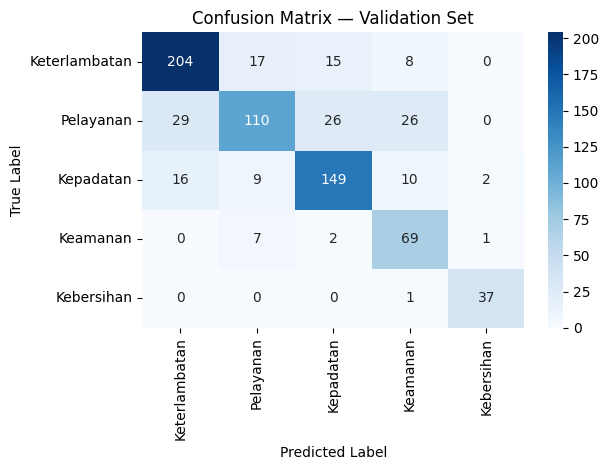

In [ ]:
# Classification Report — Validation Set
val_report_dict = classification_report(
    y_v,
    val_preds,
    target_names=le.classes_,
    output_dict=True
)
print(f"\nClassification Report — Validation Set")
print(
    classification_report(
        y_v,
        val_preds,
        target_names=le.classes_,
        digits=4
        )
    )

# Confusion Matrix — Validation Set
sns.heatmap(
    confusion_matrix(y_v, val_preds),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title(f'Confusion Matrix — Validation Set', fontsize=12)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

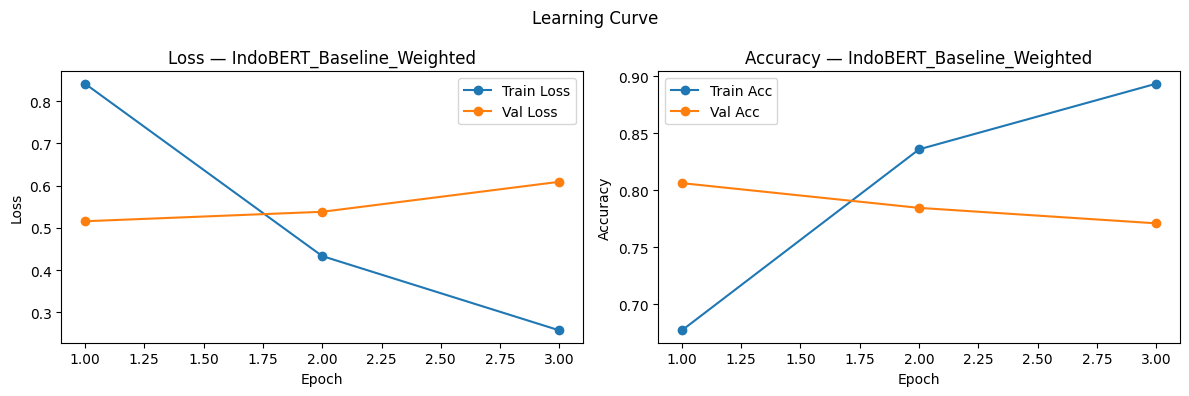

In [ ]:
# Learning Curve
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs_range, history["val_loss"],   marker="o", label="Val Loss")
plt.title(f"Loss — {MODEL_NAME}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], marker="o", label="Train Acc")
plt.plot(epochs_range, history["val_acc"],   marker="o", label="Val Acc")
plt.title(f"Accuracy — {MODEL_NAME}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.suptitle("Learning Curve")
plt.tight_layout()
plt.show()
plt.show()

Insight: menunjukkan indikasi terjadinya overfitting, di mana performa pada data pelatihan terus meningkat secara signifikan namun tidak diikuti oleh perbaikan pada data validasi. Hal ini terlihat dari train loss yang turun tajam dan train accuracy yang melonjak hingga mendekati 0,90, sementara val loss cenderung merangkak naik dan val accuracy mengalami stagnasi bahkan sedikit menurun setelah epoch kedua.

## Test Evaluation

In [ ]:
# Muat kembali bobot dari epoch terbaik
final_model.load_state_dict(torch.load("best_model.pt"))
final_model.to(device)

# Evaluasi model
test_loss, test_acc, test_preds = evaluate_model(
    final_model,
    test_loader,
    loss_fn
    )


Classification Report — Test Set
               precision    recall  f1-score   support

Keterlambatan     0.8193    0.8361    0.8276       244
    Pelayanan     0.7152    0.5885    0.6457       192
    Kepadatan     0.7548    0.8486    0.7990       185
     Keamanan     0.7073    0.7342    0.7205        79
   Kebersihan     0.8293    0.8947    0.8608        38

     accuracy                         0.7669       738
    macro avg     0.7652    0.7804    0.7707       738
 weighted avg     0.7646    0.7669    0.7633       738



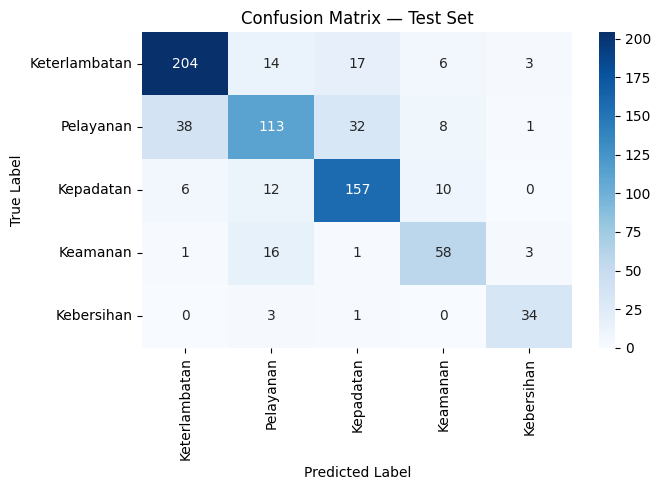

In [ ]:
# Classification Report — Test Set
test_report_dict = classification_report(
    y_te,
    test_preds,
    target_names=le.classes_,
    output_dict=True
)

print(f"\nClassification Report — Test Set")
print(
    classification_report(
        y_te,
        test_preds,
        target_names=le.classes_,
        digits=4
        )
    )

# Confusion Matrix — Test Set
plt.figure(figsize=(7, 5))

sns.heatmap(
    confusion_matrix(y_te, test_preds),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix — Test Set", fontsize=12)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [ ]:
# Ringkasan Metrik — Test Set
print("\nRingkasan Metrik (Test Set)")
print(f"  Loss            : {test_loss:.4f}")
print(f"  Accuracy        : {test_report_dict['accuracy']:.4f}")
print(f"  Macro F1        : {test_report_dict['macro avg']['f1-score']:.4f}")
print(f"  Weighted F1     : {test_report_dict['weighted avg']['f1-score']:.4f}")
print(f"  Macro Precision : {test_report_dict['macro avg']['precision']:.4f}")
print(f"  Macro Recall    : {test_report_dict['macro avg']['recall']:.4f}")


Ringkasan Metrik (Test Set)
  Loss            : 0.6175
  Accuracy        : 0.7669
  Macro F1        : 0.7707
  Weighted F1     : 0.7633
  Macro Precision : 0.7652
  Macro Recall    : 0.7804


## Simpan Model
menggunakan data eksternal

In [ ]:
import os
# Direktori penyimpanan model HuggingFace
SAVE_DIR = '/content/drive/MyDrive/skripsi/svm_indobert/model/indobert_data_2_2'

# Buat folder jika belum ada
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
# Simpan model dan tokenizer agar bisa di-load ulang tanpa training
final_model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/skripsi/svm_indobert/model/indobert_data_2_2/tokenizer_config.json',
 '/content/drive/MyDrive/skripsi/svm_indobert/model/indobert_data_2_2/tokenizer.json')

In [ ]:
# Simpan LabelEncoder dan metadata eksperimen ke file terpisah
le_bundle = {
    "le": le,                          # LabelEncoder
    "model_name": MODEL_NAME,          # Nama eksperimen
    "hf_checkpoint": HF_CHECKPOINT,    # Pretrained model

    # Evaluasi
    "val_report": val_report_dict,
    "test_report": test_report_dict,

    # Informasi split data
    "split_info": {
        "train_size": len(y_tr),
        "val_size": len(y_v),
        "test_size": len(y_te),
        "classes": list(le.classes_)
    }
}

In [ ]:
# Path file bundle
le_path = os.path.join(SAVE_DIR, "le_bundle.pkl")

# Simpan ke file pickle
with open(le_path, "wb") as f:
    pickle.dump(le_bundle, f)

In [ ]:
# Informasi lokasi penyimpanan
print("\n[INFO] Penyimpanan Model Selesai")
print(f"  Model & Tokenizer : {SAVE_DIR}")
print(f"  LabelEncoder      : {le_path}")


[INFO] Penyimpanan Model Selesai
  Model & Tokenizer : /content/drive/MyDrive/skripsi/svm_indobert/model/indobert_data_2_2
  LabelEncoder      : /content/drive/MyDrive/skripsi/svm_indobert/model/indobert_data_2_2/le_bundle.pkl


# Inferensi Model

In [ ]:
# Import library
import time
import pickle
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Config
SAVE_DIR   = '/content/drive/MyDrive/skripsi/svm_indobert/model/indobert_data_2_2'
MAX_LEN    = 128
BATCH_SIZE = 16
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"[INFO] Device: {DEVICE}")

[INFO] Device: cuda


In [ ]:
# Load  Model & Tokenizer
loaded_model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR)
loaded_model.to(DEVICE)
loaded_model.eval()  # mode inference

loaded_tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
# Load Label Encoder dari file pickle
with open(f"{SAVE_DIR}/le_bundle.pkl", "rb") as f:
    bundle = pickle.load(f)

loaded_le = bundle["le"]

In [ ]:
# Prepare Data
df_ext = pd.read_csv(
    "/content/drive/MyDrive/skripsi/svm_indobert/data/final_data/2026_krl_complaints_preprocessed_4.csv"
)
texts = df_ext["text_bert"].tolist()
y_ext_true = loaded_le.transform(df_ext["label"])

n_samples = len(texts)
print(f"[INFO] Jumlah data: {n_samples}")

# Class Distribution (External Data)
dist_counts = df_ext["label"].value_counts()
dist_pct = dist_counts / dist_counts.sum() * 100

dist_table = pd.DataFrame({
    'Frekuensi': dist_counts,
    'Persentase (%)': dist_pct.round(2)
})

print('\nDistribusi Label (External Data):')
print(dist_table.to_string())

[INFO] Jumlah data: 491

Distribusi Label (External Data):
               Frekuensi  Persentase (%)
label                                   
Keterlambatan        204           41.55
Pelayanan            125           25.46
Kepadatan            116           23.63
Keamanan              29            5.91
Kebersihan            17            3.46


In [ ]:
# Batch Inference
all_preds = []

start_time = time.perf_counter()  # Timing Start
print("\n[INFO] Memulai inference (batching)...")

for i in range(0, len(texts), BATCH_SIZE):

    batch_texts = texts[i:i + BATCH_SIZE]

    # Tokenisasi batch
    encodings = loaded_tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

    # Pindahkan ke device
    encodings = {k: v.to(DEVICE) for k, v in encodings.items()}

    # Inference
    with torch.no_grad():
        outputs = loaded_model(**encodings)
        logits  = outputs.logits
        preds   = torch.argmax(logits, dim=1)

    # Simpan hasil ke CPU
    all_preds.extend(preds.cpu().numpy())

end_time = time.perf_counter()  # Timing End

# Convert ke numpy array
ext_preds = np.array(all_preds)


[INFO] Memulai inference (batching)...



 Classification Report (External Data)
               precision    recall  f1-score   support

Keterlambatan     0.9011    0.8039    0.8497       204
    Pelayanan     0.7670    0.6320    0.6930       125
    Kepadatan     0.6957    0.8276    0.7559       116
     Keamanan     0.3958    0.6552    0.4935        29
   Kebersihan     0.6500    0.7647    0.7027        17

     accuracy                         0.7556       491
    macro avg     0.6819    0.7367    0.6990       491
 weighted avg     0.7799    0.7556    0.7615       491



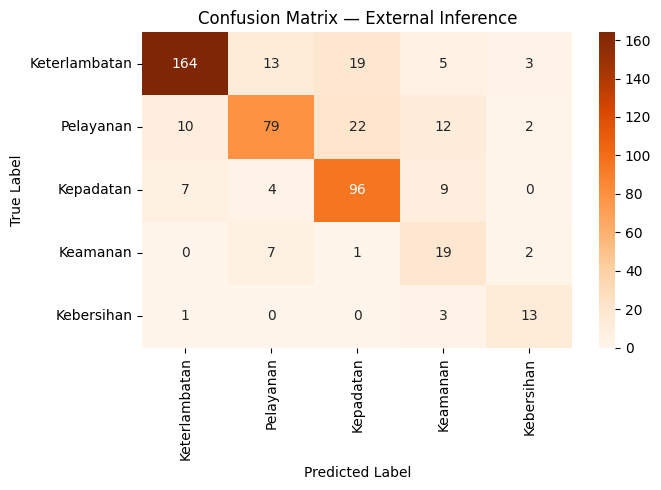

In [ ]:
# Evaluation

# Classification Report
ext_report_dict = classification_report(
    y_ext_true,
    ext_preds,
    target_names=loaded_le.classes_,
    output_dict=True
)

print('\n Classification Report (External Data)')
print(
    classification_report(
        y_ext_true,
        ext_preds,
        target_names=loaded_le.classes_,
        digits=4
    )
)

# Confusion Matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    confusion_matrix(y_ext_true, ext_preds),
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=loaded_le.classes_,
    yticklabels=loaded_le.classes_
)

plt.title('Confusion Matrix — External Inference')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

In [ ]:
# Summary Matrix
print('\n Ringkasan Metrik (External Data)')
print(f"  Accuracy        : {ext_report_dict['accuracy']:.4f}")
print(f"  Macro F1        : {ext_report_dict['macro avg']['f1-score']:.4f}")
print(f"  Weighted F1     : {ext_report_dict['weighted avg']['f1-score']:.4f}")
print(f"  Macro Precision : {ext_report_dict['macro avg']['precision']:.4f}")
print(f"  Macro Recall    : {ext_report_dict['macro avg']['recall']:.4f}")


 Ringkasan Metrik (External Data)
  Accuracy        : 0.7556
  Macro F1        : 0.6990
  Weighted F1     : 0.7615
  Macro Precision : 0.6819
  Macro Recall    : 0.7367


In [ ]:
# Timing Result
total_time = end_time - start_time
time_per_sample = total_time / n_samples
throughput = n_samples / total_time

print('\nWaktu Inference (End-to-End)')
print(f'  Total waktu        : {total_time:.4f} detik')
print(f'  Waktu per sampel   : {time_per_sample:.6f} detik')
print(f'  Throughput         : {throughput:.2f} sampel/detik')


Waktu Inference (End-to-End)
  Total waktu        : 1.7139 detik
  Waktu per sampel   : 0.003491 detik
  Throughput         : 286.47 sampel/detik
